# WMO Support Dataset (formerly SOFF): WMO NMHS Operational Data Access

---

## Learning objectives

1. Understand what WMO Support Dataset provides beyond the free open data tier
2. Connect to the ECPDS dissemination system and navigate the file structure
3. Inspect a real WMO Support Dataset surface file with earthkit
4. Understand CCSDS packing and how to convert for WRF/WPS
5. Compare resolution: WMO Support Dataset (0.1°) vs Open Data (0.25°)

---

## Introduction

**WMO Support Dataset** (Sustained Observing and Forecasting Facility) provides **IFS deterministic** forecasts
at **0.1° resolution** to WMO Member NMHSs **free of charge**.

Key differences from ECMWF Open Data:

| | Open Data | WMO Support Dataset |
|---|---|---|
| Resolution | 0.25° | **0.1°** |
| Model levels | ✗ | **✓ all 137 levels** |
| Credentials | None | WMO account (`wmo_xx`) or ECPDS account |
| Forecast range | 0-360 h | 0-90 h |
| Models | IFS ENS, AIFS, waves | IFS deterministic only |

The 137 model-level fields (T, U, V, W, Q, LNSP) are what you need to **initialise a
Limited Area Model (WRF, HARMONIE, ALADIN)**.
Open Data does not include model levels.

> **To get access:** Contact your WMO focal point to activate `wmo_xx` credentials,
> or raise a ticket at [support.ecmwf.int](https://support.ecmwf.int).


## 1) Setup

In [67]:
import netrc
creds = netrc.netrc().authenticators("diss.ecmwf.int")
# print(repr(creds[2]))  # should show 'rSO$2r5X'

In [68]:
from pathlib import Path
import earthkit.data as ekd
import numpy as np
import matplotlib.pyplot as plt

try:
    from _utils import get_data_dir
    DATA_DIR = Path(get_data_dir())
except Exception:
    DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data cache:", DATA_DIR)


Data cache: /Users/valtze/ecmwf-open-data-guide/data


## 2) FTP structure and filename convention

WMO Support Dataset data is disseminated via the ECMWF ECPDS system at `diss.ecmwf.int`.

**Authentication:**
- WMO NMHS accounts (`wmo_xx`): static password, land directly in date folders
- Internal ECMWF accounts (e.g. `ecm0679`): static ECPDS password, have `SF1/SF2/SF3` prefix

**Directory structure for wmo_xx accounts:**
```
diss.ecmwf.int/
  20260514/
    FMD05141200051600001   ← model levels (~75 MB)
    FSD05141200051600001   ← surface fields (~4 MB)
    FPD05141200051600001   ← pressure levels (~5 MB)
    AND05141800051418001   ← analysis notification
```

**Directory structure for internal accounts (SF prefix):**
```
diss.ecmwf.int/
  SF1/
    20260514/
      FMD05141200051600001
      FSD05141200051600001
      ...
```

**Filename convention:** `FSD 0514 12 00 51 600 001`
- `F` = forecast
- `S` = surface (`M` = model levels, `P` = pressure levels)
- `D` = deterministic
- `0514` = date (14 May)
- `12` = run time (12z)
- `00` = step 00h
- `51` = cycle identifier (50r1)
- `600` = step/level sequence
- `001` = chunk index


## 3) Connect and download via FTP

The cell below connects to ECPDS and downloads a surface file.

**For wmo_xx accounts:** use `cd YYYYMMDD` directly after login.
**For internal accounts:** use `cd SF1` first, then `cd YYYYMMDD`.

> **Note:** You will be prompted for your ECPDS password.
> This is a **static password** (not a TOTP/RSA token) specific to the dissemination system.
> Login at [diss.ecmwf.int/ecpds/data/list/](https://diss.ecmwf.int/ecpds/data/list/) to verify.


In [69]:
import ftplib
import netrc
from datetime import datetime, timezone, timedelta

FTP_HOST = "diss.ecmwf.int"
FTP_USER = "ecm0679"          # change to your wmo_xx or ECPDS username

# Pick a date with available data
now = datetime.now(timezone.utc)
date_str = (now - timedelta(days=1)).strftime("%Y%m%d")
print(f"Connecting to {FTP_HOST} as {FTP_USER} ...")
print(f"Target date: {date_str}")

LOCAL_PATH = DATA_DIR / f"soff_surface_{date_str}_12z_step0.grib2"

if LOCAL_PATH.exists() and LOCAL_PATH.stat().st_size > 0:
    print(f"Already cached: {LOCAL_PATH.name} ({LOCAL_PATH.stat().st_size/1e6:.1f} MB)")
else:
    # Read password from ~/.netrc (no prompt needed)
    # Setup: echo "machine diss.ecmwf.int login ecm0679 password YOUR_PW" >> ~/.netrc && chmod 600 ~/.netrc
    try:
        creds = netrc.netrc().authenticators(FTP_HOST)
        password = creds[2] if creds else None
        if not password:
            raise ValueError("No credentials found in ~/.netrc for diss.ecmwf.int")
    except Exception as e:
        print(f"~/.netrc not set up: {e}")
        print("Add credentials: echo \"machine diss.ecmwf.int login ecm0679 password YOUR_PW\" >> ~/.netrc && chmod 600 ~/.netrc")
        password = None

    if password:
        try:
            ftp = ftplib.FTP(FTP_HOST)
            ftp.login(user=FTP_USER, passwd=password)
            print("Logged in successfully")

            # Navigate: internal accounts need SF1 prefix
            try:
                ftp.cwd("SF1")
                print("Navigated to SF1/ (internal account)")
            except ftplib.error_perm:
                print("No SF prefix (wmo_xx account)")

            ftp.cwd(date_str)
            files = ftp.nlst()
            surface_files = sorted([f for f in files if f.startswith("FSD")])
            print(f"Surface files available: {len(surface_files)}")
            if surface_files:
                print(f"First: {surface_files[0]}")

            # Download step 0 surface file
            target = surface_files[0] if surface_files else None
            if target:
                print(f"Downloading: {target} ...")
                with open(LOCAL_PATH, "wb") as f:
                    ftp.retrbinary(f"RETR {target}", f.write)
                print(f"Done: {LOCAL_PATH.name} ({LOCAL_PATH.stat().st_size/1e6:.1f} MB)")
            ftp.quit()
        except Exception as e:
            print(f"FTP error: {e}")
            LOCAL_PATH = None

# Fallback to pre-downloaded file
if not LOCAL_PATH or not LOCAL_PATH.exists():
    fallback = DATA_DIR / "FSD05141200051600001"
    if fallback.exists():
        LOCAL_PATH = fallback
        print(f"Using pre-downloaded file: {LOCAL_PATH.name}")
    else:
        print("No WMO Support Dataset file found. Run FTP cell or place FSD* file in data/")
        LOCAL_PATH = None


Connecting to diss.ecmwf.int as ecm0679 ...
Target date: 20260519
Already cached: soff_surface_20260519_12z_step0.grib2 (3.7 MB)


## 4) Inspect the surface file with earthkit

Once downloaded, we open the WMO Support Dataset surface file exactly like any other GRIB: the same earthkit API works for WMO Support Dataset, open data, and ERA5.


In [70]:
# Open and inspect with earthkit
if LOCAL_PATH and Path(LOCAL_PATH).exists():
    ds = ekd.from_source("file", str(LOCAL_PATH))
    print(f"File: {Path(LOCAL_PATH).name}")
    print(f"Messages: {len(ds)}")
    print()

    # Show key metadata for each field
    print(f"{'shortName':12} {'typeOfLevel':20} {'level':8} {'step':6} {'dataType':10} {'packingType'}")
    print("-" * 75)
    for i, f in enumerate(ds):
        sn   = f.metadata("shortName")
        tol  = f.metadata("typeOfLevel")
        lev  = f.metadata("level")
        step = f.metadata("step")
        dt   = f.metadata("dataType")
        pk   = f.metadata("packingType")
        print(f"{sn:12} {tol:20} {lev:<8} {step:<6} {dt:10} {pk}")
else:
    print("No WMO Support Dataset file available - run the FTP cell first")


File: soff_surface_20260519_12z_step0.grib2
Messages: 26

shortName    typeOfLevel          level    step   dataType   packingType
---------------------------------------------------------------------------
z            surface              0        0      fc         grid_simple
lsm          surface              0        0      fc         grid_simple
swvl3        depthBelowLandLayer  28       0      fc         grid_simple
swvl1        depthBelowLandLayer  0        0      fc         grid_simple
sst          surface              0        0      fc         grid_simple
stl2         depthBelowLandLayer  7        0      fc         grid_simple
swvl2        depthBelowLandLayer  7        0      fc         grid_simple
ssr          surface              0        0      fc         grid_simple
sd           surface              0        0      fc         grid_simple
stl3         depthBelowLandLayer  28       0      fc         grid_simple
tp           surface              0        0      fc         gr

## 5) Plot: 2m temperature from WMO Support Dataset

Same plotting workflow as 03: earthkit handles WMO Support Dataset files identically.


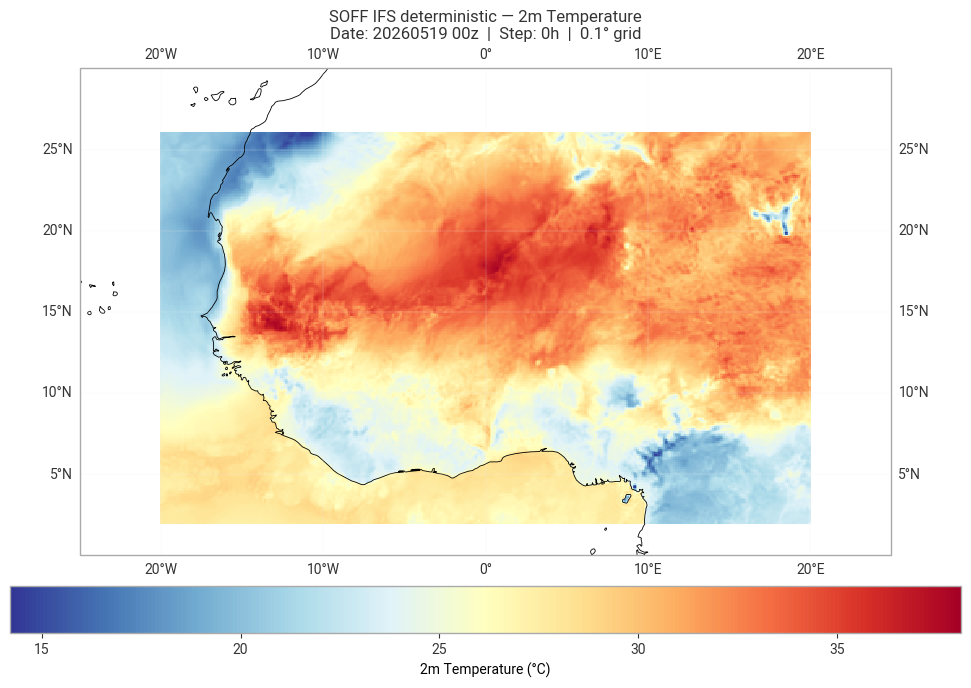

Grid spacing: 0.1° | Shape: (241, 460) | min: 14.2°C  max: 38.1°C


In [71]:
import cartopy.crs as ccrs

if LOCAL_PATH and Path(LOCAL_PATH).exists():
    ds = ekd.from_source("file", str(LOCAL_PATH))

    # Select 2m temperature
    try:
        fld = ds.sel(shortName="2t")[0]
    except Exception:
        fld = ds[0]
        print(f"Note: using first field ({fld.metadata('shortName')})")

    xa = fld.to_xarray()
    if hasattr(xa, 'data_vars'):
        var = list(xa.data_vars)[0]
        t2m = xa[var] - 273.15  # K to °C
    else:
        t2m = xa - 273.15

    # Plot over Africa
    fig, ax = plt.subplots(figsize=(10, 7),
                            subplot_kw={"projection": ccrs.PlateCarree()})
    ax.set_extent([-25, 25, 0, 30], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.6)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    im = t2m.sel(latitude=slice(40, -40), longitude=slice(-20, 55)).plot(
        ax=ax, transform=ccrs.PlateCarree(),
        cmap="RdYlBu_r", add_colorbar=True,
        cbar_kwargs={"label": "2m Temperature (°C)", "orientation": "horizontal", "pad": 0.05}
    )
    f0 = ds[0]
    ax.set_title(
        f"WMO Support Dataset IFS deterministic - 2m Temperature\n"
        f"Date: {f0.metadata('date')} {f0.metadata('time'):02d}z  |  Step: {f0.metadata('step')}h  |  0.1° grid"
    )
    plt.tight_layout()
    plt.show()
    print(f"Grid spacing: 0.1° | Shape: {t2m.shape} | "
          f"min: {float(t2m.min()):.1f}°C  max: {float(t2m.max()):.1f}°C")
else:
    print("No WMO Support Dataset file available")


## 6) CCSDS packing: convert before WRF/WPS

WMO Support Dataset model-level files (`FMD*`) use **CCSDS compression**.
Most tools including WRF's WPS/ungrib cannot read this directly.

> **Surface files (`FSD*`) may use `grid_simple` already**: check with `grib_ls`.
> Model-level files (`FMD*`) always require conversion.


In [72]:
# Check packing type of the downloaded file
if LOCAL_PATH and Path(LOCAL_PATH).exists():
    ds = ekd.from_source("file", str(LOCAL_PATH))
    packing = ds[0].metadata("packingType")
    print(f"File: {Path(LOCAL_PATH).name}")
    print(f"Packing type: {packing}")
    if packing == "grid_ccsds":
        print("\n⚠ CCSDS packing detected - convert before WPS:")
        print()
        print("  grib_set -s packingType=grid_simple input.grib output.grib")
        print()
        print("For model-level files (FMD*) only CCSDS messages:")
        print("  grib_set -r -w packingType=grid_ccsds -s packingType=grid_simple FMD* FMD*_simple.grib2")
    else:
        print(f"✓ No conversion needed (packing: {packing})")
    print()
    print("Note: IFS 50r2 (Q3 2026) will remove CCSDS - this step becomes unnecessary")
else:
    print("No WMO Support Dataset file available")


File: soff_surface_20260519_12z_step0.grib2
Packing type: grid_simple
✓ No conversion needed (packing: grid_simple)

Note: IFS 50r2 (Q3 2026) will remove CCSDS — this step becomes unnecessary


## 7) Resolution comparison: WMO Support Dataset (0.1°) vs Open Data (0.25°)

We compare the grid spacing to show what higher resolution gives you for Africa.


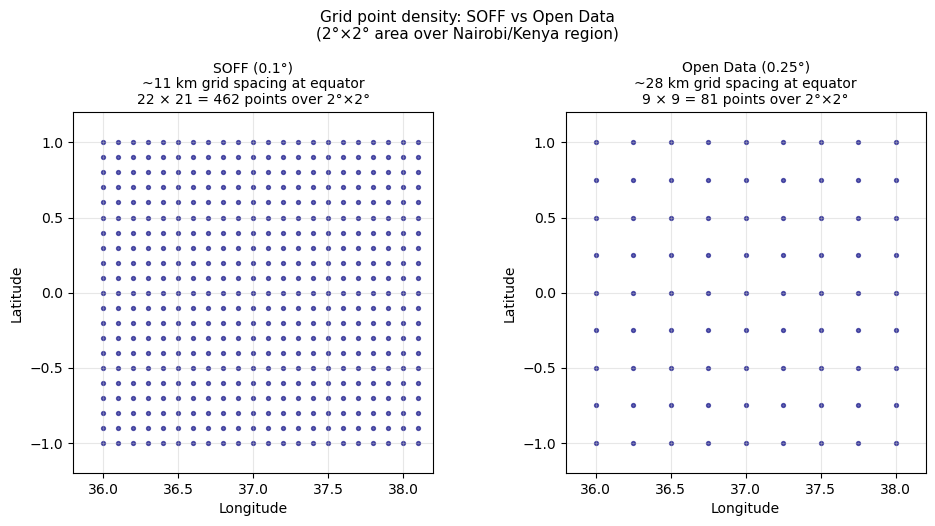

At the equator:
  SOFF (0.1°): 11 km grid spacing
  Open Data (0.25°): 28 km grid spacing

For convection-permitting LAMs (WRF at 3-9 km):
  → SOFF 0.1° boundary conditions are meaningfully better than Open Data 0.25°
  → Model levels (137) vs pressure levels (6): critical for accurate LAM initialisation


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Grid spacing in degrees
resolutions = {"Grid data (0.25°)": 0.25, "Grid Data (0.1°)": 0.1}

# Approximate km at equator (1° ≈ 111 km)
km_per_deg = 111.0

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (label, res) in zip(axes, resolutions.items()):
    # Show a 2° × 2° patch at equator (e.g. over Kenya)
    lons = np.arange(36, 38 + res, res)
    lats = np.arange(-1, 1 + res, res)
    lon2d, lat2d = np.meshgrid(lons, lats)

    ax.scatter(lon2d, lat2d, s=8, color="navy", alpha=0.6)
    ax.set_title(f"{label}\n~{res * km_per_deg:.0f} km grid spacing at equator\n"
                 f"{len(lons)} × {len(lats)} = {len(lons)*len(lats)} points over 2°×2°",
                 fontsize=10)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_xlim(35.8, 38.2); ax.set_ylim(-1.2, 1.2)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

plt.suptitle("Grid point density\n(2°×2° area over Nairobi/Kenya region)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("At the equator:")
for label, res in resolutions.items():
    km = res * km_per_deg
    print(f"  {label}: {km:.0f} km grid spacing")
print()
print("For convection-permitting LAMs (WRF at 3-9 km):")
print("  → 0.1° boundary conditions are meaningfully better than Open Data 0.25°")
print("  → Model levels (137) vs pressure levels (6): critical for accurate LAM initialisation")


## 8) WMO Support Dataset model-level fields for WRF initialisation

| Parameter | shortName | Levels | Why it matters |
|---|---|---|---|
| Temperature | `t` | 137 | Full temperature profile |
| U wind | `u` | 137 | Horizontal wind east-west |
| V wind | `v` | 137 | Horizontal wind north-south |
| Vertical velocity | `w` | 137 | Vertical motion |
| Specific humidity | `q` | 137 | Moisture profile |
| Ln surface pressure | `lnsp` | 1 | Required to compute pressure on model levels |
| Cloud liquid water | `clwc` | 137 | Improves hydrometeor initialisation |
| Cloud ice water | `ciwc` | 137 | Improves hydrometeor initialisation |

Open Data provides only **6 pressure levels** (100, 200, 250, 500, 850, 1000 hPa) which is for most applications
insufficient for high-resolution LAM initialisation over complex terrain (for example East Africa, Sahel).


## Take-home messages

- **WMO Support Dataset = 0.1°, 137 model levels**: the key differentiator for LAM/WRF users
- **Access**: FTP via `diss.ecmwf.int` with static ECPDS password
  - `wmo_xx` accounts: navigate `YYYYMMDD/` directly
  - Internal ECMWF accounts: navigate `SF1/YYYYMMDD/` first
- **Filename convention**: `FMD DDMM RR SS CC LLL NNN`: FM=model levels, FS=surface, FP=pressure levels
- **CCSDS packing**: convert model-level files before WRF/WPS with `grib_set -s packingType=grid_simple`
  - Goes away with IFS 50r2 (Q3 2026)
- **WMO Support Dataset surface fields** include soil moisture/temperature (4 layers), SST, snow: useful for IbF applications
- **ecCharts**: WMO NMHS `wmo_xx` credentials also include one free ecCharts account (WMS access)
- **Get access**: raise a ticket at [support.ecmwf.int](https://support.ecmwf.int)

### Next notebooks
- **Notebooks 01-04**: Back to open data - 04 covers cloud endpoints (AWS/Azure/GCS)
- **Notebooks 05-07**: Copernicus - ERA5, seasonal, CAMS dust
